In [50]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from pandas.core.interchange.dataframe_protocol import DataFrame

from src.util.model_utils import read_jsonl

data = read_jsonl("/Users/amir/Data/Projects/SQL_parser/data/din_bird_logs/util.jsonl")


In [229]:
metric = "cpu"
rows = []
for row in data:
    ts = row['record']['time']['timestamp']
    ts = int(ts)
    util = row['record']['extra']['util']
    m = util['cpu']
    rows.append({"ts": ts, metric: cpu})

df = pd.DataFrame(rows)
df.head()


,ts,cpu
0,1741120966,69.9
1,1741120968,79.8
2,1741120969,49.9
3,1741120971,209.5
4,1741120973,389.4


In [65]:
refined = df.copy()
refined['ts'] = refined['ts'] - refined['ts'].min()
refined['cpu'] = refined['cpu'] / 100
refined['cpu'] = refined['cpu'].round(2)
refined.head()


,ts,cpu
0,0,0.70
1,2,0.80
2,3,0.50
3,5,2.10
4,7,3.89


In [225]:


def split(rows):
    splits = []
    prev_ts = 0
    to_sub = 0
    for row in rows:
        ts = row.ts
        orig_ts = ts
        ts -= to_sub
        diff = ts - prev_ts
        if diff > 10:
            ts -= diff - 1
            to_sub += diff - 1
            print(f"DIFF FOUND @:{orig_ts}: diff={diff}, prev={prev_ts}, new_ts={ts}")
            splits.append(orig_ts)
        prev_ts = ts
    return splits

def get_around(d, ts):
    target_index = d.index[d['ts'] == ts][0]  # First occurrence
    start = max(target_index - 5, 0)
    end = min(target_index + 5, len(d) - 1)
    subset = d.loc[start:end]
    return subset

def draw_range(start = 0, end = len(refined)):
    filtered = refined.copy()
    filtered = filtered[(filtered['ts'] > start) & (filtered['ts'] < end)]
    plt.figure(figsize=(30, 6))
    sns.lineplot(data=filtered, x="ts", y="cpu")
    plt.show()


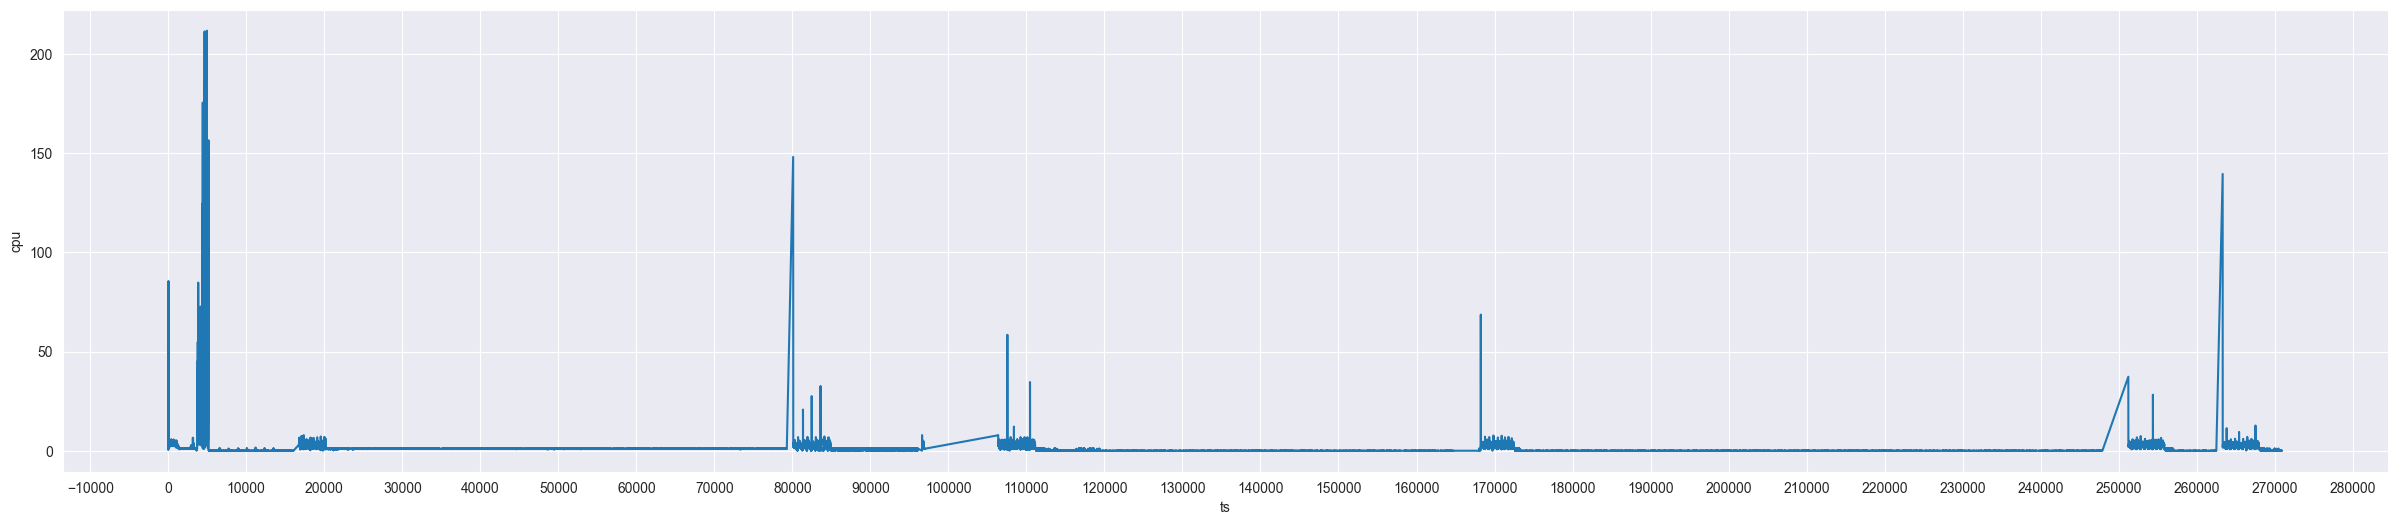

In [213]:

plt.figure(figsize=(30, 6))
sns.lineplot(data=refined, x="ts", y="cpu")
# plt.xticks([0, 2, 4, 6, 8, 10])
plt.locator_params(axis='x', nbins=40)
plt.show()


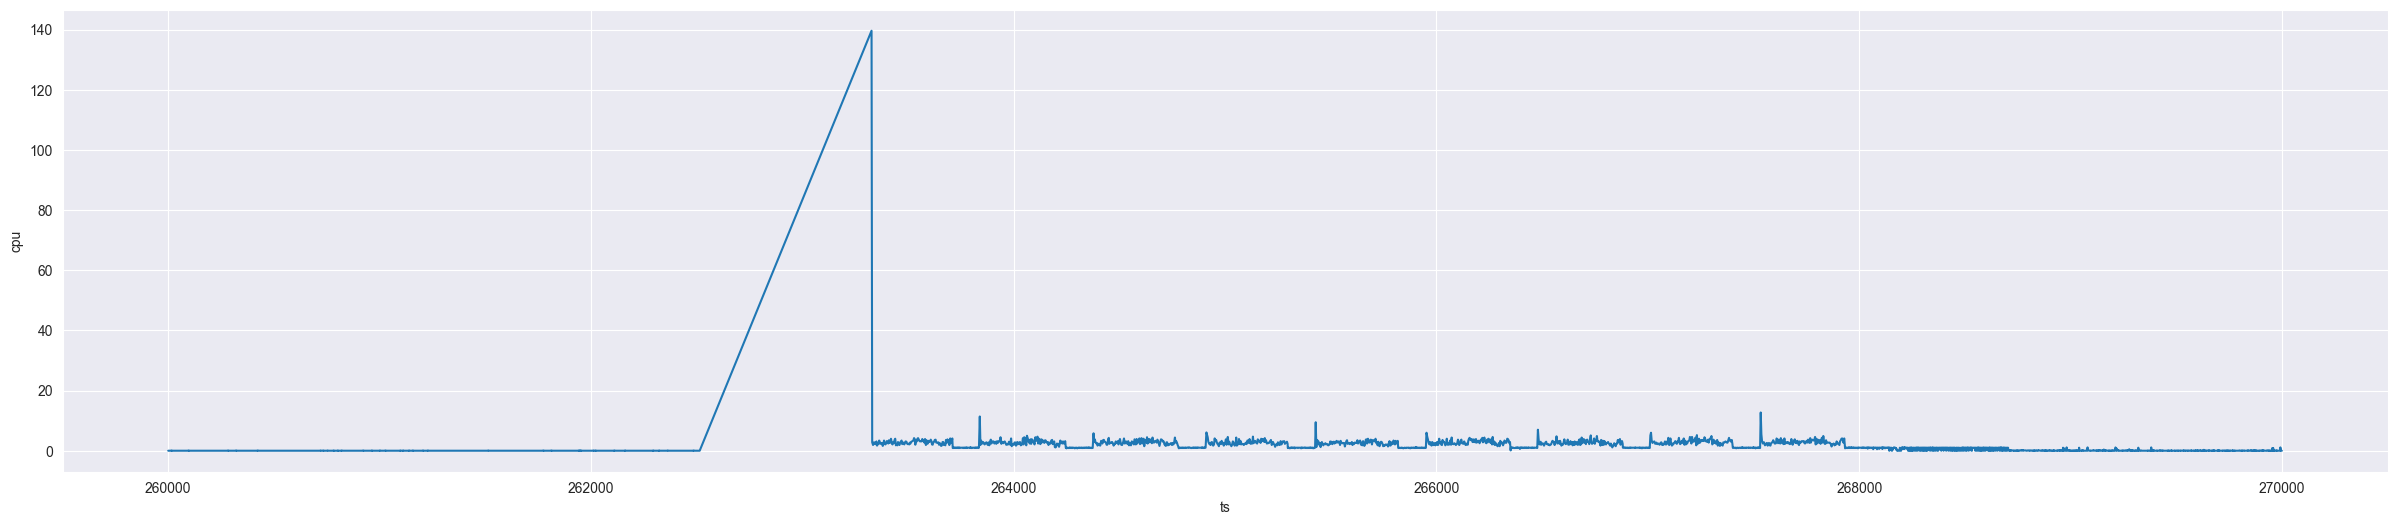

In [228]:
# draw_range(0,10_000)
# draw_range(10_000,20_000)
# draw_range(80_000,85_000)
# draw_range(95_000,120_000)
# draw_range(165_000,175_000)
# draw_range(240_000,260_000)
# draw_range(260_000,270_000)

